# Assignment 1

- Tutorial: [Image Classification from Scratch](https://keras.io/examples/vision/image_classification_from_scratch/)


# Load and Visualize CIFAR-10


(50000, 32, 32, 3)


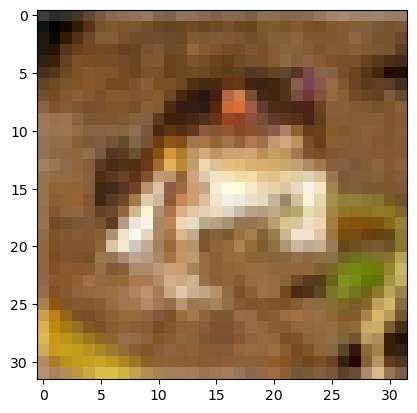

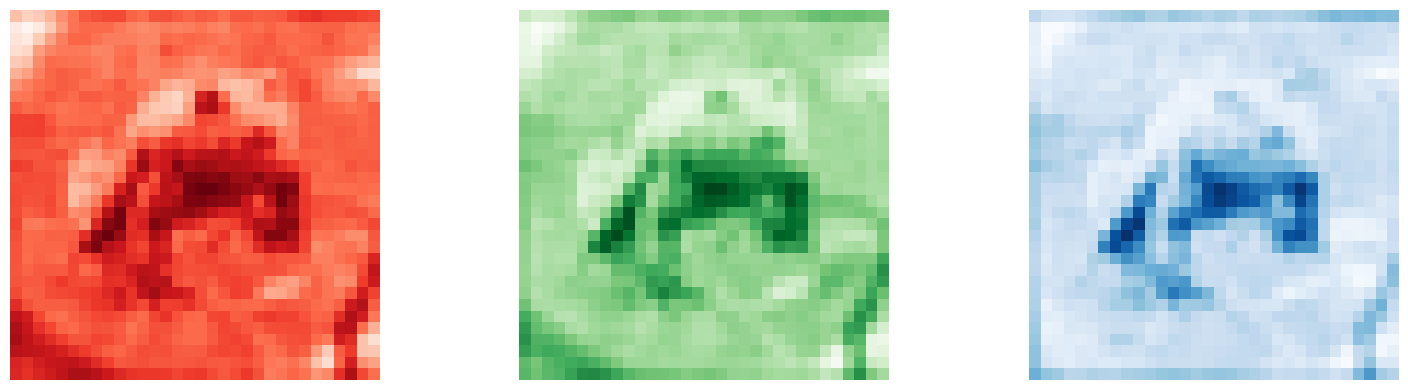

In [6]:
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from tensorflow.data import Dataset, AUTOTUNE


(training_set_x, training_set_y), (test_set_x, test_set_y) = cifar10.load_data()
print(training_set_x.shape)

image = training_set_x[0]
plt.imshow(image)

red = image[:, :, 0]
green = image[:, :, 1]
blue = image[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(red, cmap="Reds")
axes[0].axis("off")

axes[1].imshow(green, cmap="Greens")
axes[1].axis("off")

axes[2].imshow(blue, cmap="Blues")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Data Preparation

- Option 2 from tutorial, training will be on CPU
- Data augmentation


In [7]:
from keras import layers, Input, Sequential, utils
import numpy as np


factor = 0.02
zoom_factor = (-factor, factor)

indices = np.arange(training_set_x.shape[0])
np.random.seed(42)
np.random.shuffle(indices)

training_set_x = training_set_x[indices]
training_set_y = training_set_y[indices]

training_set_y = training_set_y.flatten()
test_set_y = test_set_y.flatten()

augmentation_layers = Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor),
        layers.RandomZoom(height_factor=zoom_factor, width_factor=zoom_factor),
        layers.RandomTranslation(height_factor=factor, width_factor=factor),
    ]
)

batch_size = 64

# Model Building

- VGG architecture, 3 convolution blocks
- Each block: (Convolution + Batch Normalization + Activation) \* 2 + Max Pooling(size 2, stride 2) + Dropout


In [8]:
from keras import regularizers

regularizer_penalty = 1e-4


def BlockGenerator(filters: int, dropout_rate: float, input):
    input = layers.Conv2D(
        filters=filters,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.L2(regularizer_penalty),
    )(input)
    input = layers.BatchNormalization()(input)
    input = layers.Activation("relu")(input)

    input = layers.Conv2D(
        filters=filters,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.L2(regularizer_penalty),
    )(input)
    input = layers.BatchNormalization()(input)
    input = layers.Activation("relu")(input)

    input = layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2))(input)
    result = layers.Dropout(rate=dropout_rate)(input)

    return result


def ClassifierBlockGenerator(class_number: int, nodes: int, dropout_rate: float, input):
    input = layers.GlobalAveragePooling2D()(input)
    input = layers.Dense(
        units=nodes, kernel_regularizer=regularizers.L2(regularizer_penalty)
    )(input)
    input = layers.BatchNormalization()(input)
    input = layers.Activation("relu")(input)
    input = layers.Dropout(rate=dropout_rate)(input)
    result = layers.Dense(units=class_number, activation="softmax")(input)

    return result

In [9]:
from keras import Model

image_shape = (32, 32, 3)
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

input_block = Input(shape=image_shape)

rescaling_block = layers.Rescaling(scale=1 / 255)(input_block)

augmentation_block = augmentation_layers(rescaling_block)

block_1 = BlockGenerator(filters=128, dropout_rate=0.2, input=augmentation_block)
block_2 = BlockGenerator(filters=256, dropout_rate=0.3, input=block_1)
block_3 = BlockGenerator(filters=512, dropout_rate=0.4, input=block_2)

output_block = ClassifierBlockGenerator(
    class_number=len(classes), nodes=256, dropout_rate=0.6, input=block_3
)

model = Model(inputs=input_block, outputs=output_block, name="Assignment_1")
model.summary()

Model: "Assignment_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,718,474 (18.00 MB)

 Trainable params: 4,714,378 (17.98 MB)

 Non-trainable params: 4,096 (16.00 KB)

# Model Optimization

- Adam
- Learning rate decay


In [10]:
from keras import optimizers, losses, metrics, callbacks

epochs = 100


cosineDecay = optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001, decay_steps=epochs * 625
)
optimizer = optimizers.Adam(learning_rate=cosineDecay)

model.compile(
    optimizer=optimizer,
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy(name="accuracy")],
)

callback_list = [
    # callbacks.ReduceLROnPlateau(factor=0.5, patience=5, verbose=1, min_lr=1e-6),
    callbacks.EarlyStopping(
        monitor="val_loss", patience=20, verbose=1, restore_best_weights=True
    ),
    callbacks.ModelCheckpoint("checkpoints/at_{epoch}.keras"),
]

# Training


In [ ]:
history = model.fit(
    x=training_set_x,
    y=training_set_y,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=callback_list,
    verbose=1,
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 715s 909ms/step - accuracy: 0.3885 - loss: 1.7060 - val_accuracy: 0.4572 - val_loss: 1.5641
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 752s 962ms/step - accuracy: 0.5338 - loss: 1.3056 - val_accuracy: 0.3820 - val_loss: 2.3768
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 730s 933ms/step - accuracy: 0.5973 - loss: 1.1480 - val_accuracy: 0.4685 - val_loss: 1.6993
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 725s 927ms/step - accuracy: 0.6428 - loss: 1.0366 - val_accuracy: 0.6192 - val_loss: 1.1903
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 732s 936ms/step - accuracy: 0.6765 - loss: 0.9433 - val_accuracy: 0.6700 - val_loss: 0.9919
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 758s 969ms/step - accuracy: 0.6993 - loss: 0.8756 - val_accuracy: 0.6030 - val_loss: 1.4293
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 768s 982ms/step - accuracy: 0.7236 - loss: 0.8190 - val_accuracy: 0.6863 - val_loss: 0.9742
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 780s 997ms/step - accuracy: 0.7369 -

KeyboardInterrupt: 

In [ ]:
# from keras import models

# model_2 = models.load_model("checkpoints/at_11.keras")

# history_2 = model_2.fit(
#     training_set,
#     validation_data=val_set,
#     epochs=50,
#     initial_epoch=11,
#     callbacks=callback_list,
#     verbose=1,
# )

# Plotting Accuracy


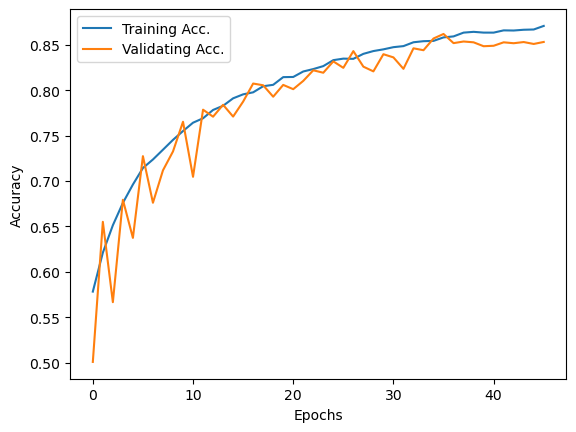

In [33]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

plt.plot(accuracy, label="Training Acc.")
plt.plot(val_accuracy, label="Validating Acc.")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Quantize Model


In [ ]:
# from tensorflow import lite

# interpreter = lite.Interpreter(
#     "best/at_93-15_6_2026.keras",
#     experimental_delegates=[
#         lite.experimental.load_delegate("nnapi.so")
#     ]
# )

# Model Evaluation


157/157 ━━━━━━━━━━━━━━━━━━━━ 63s 395ms/step - accuracy: 0.9122 - loss: 0.5390
Test Loss: 0.5390
Test Accuracy: 91.22%


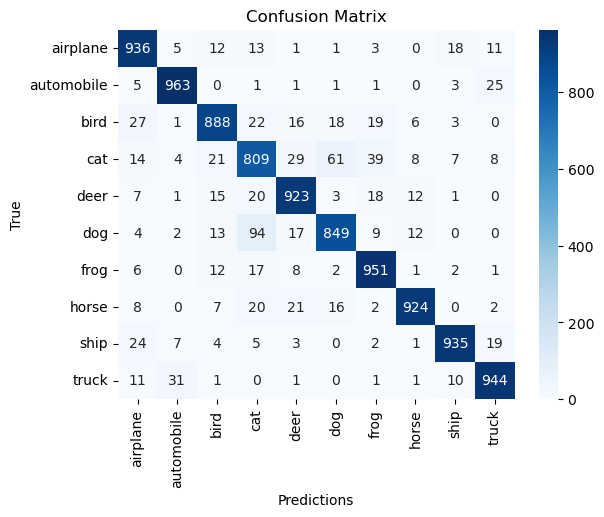

In [5]:
from keras import models
from sklearn.metrics import confusion_matrix
import seaborn as sns

model = models.load_model("best/at_93-15_6_2026.keras")
batch_size=64

test_loss, test_accuracy = model.evaluate(test_set_x, test_set_y, batch_size, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

predictions = model.predict(test_set_x, batch_size, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

conf_matrix = confusion_matrix(test_set_y, predicted_classes)

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)
plt.title("Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predictions")
plt.show()